In [1]:
# LightGBM Regression for Medical Insurance Cost Prediction
# Author: MANIKANDAPRABHU.S
# Objective: Predict medical insurance charges using LightGBM regression with hyperparameter tuning.


In [2]:
## 1. Import Libraries
import pandas as pd


In [3]:
## 2. Loading the Dataset
dataset=pd.read_csv("insurance_pre.csv")

In [4]:
## 3. Exploring the Dataset
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [5]:
## 4. Encoding Categorical Variables
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)

In [6]:
## 5. Checking the Prepared Dataset
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


In [7]:
## 6. Preparing Features and Target Variable
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [8]:
## 7. Installing LightGBM
inde=dataset[['age', 'bmi', 'children','sex_male', 'smoker_yes']]
dep=dataset[ 'charges']


In [9]:
## 8. Training LightGBM Regression Model with Hyperparameter Tuning
! pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 644.1 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 644.1 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 644.1 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 644.1 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 644.1 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 644

In [10]:
## 9. Checking the Best Parameters
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
param_grid={'boosting_type':['gbdt'],'num_leaves':[20,31],'n_estimators':[20,40,60,100]}

grid=GridSearchCV( LGBMRegressor(),param_grid,refit=True,verbose=3,n_jobs=-1)
grid.fit(inde,dep)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 1338, number of used features: 5
[LightGBM] [Info] Start training from score 13270.422260


,estimator,LGBMRegressor()
,param_grid,"{'boosting_type': ['gbdt'], 'n_estimators': [20, 40, ...], 'num_leaves': [20, 31]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [11]:
## 10. Creating the Grid Search Results Table
find=grid.cv_results_
print(" The R_value for best parametor{}:".format(grid.best_params_))

 The R_value for best parametor{'boosting_type': 'gbdt', 'n_estimators': 40, 'num_leaves': 20}:


In [12]:
## 11. Displaying the Grid Search Results
table=pd.DataFrame.from_dict(find)

In [13]:
## 12. Taking New Customer Input
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_boosting_type,param_n_estimators,param_num_leaves,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,16.998031,0.041752,0.008386,0.002369,gbdt,20,20,"{'boosting_type': 'gbdt', 'n_estimators': 20, ...",0.869348,0.802543,0.870729,0.838053,0.850094,0.846153,0.025000,4
1,10.377902,8.163367,0.005249,0.000991,gbdt,20,31,"{'boosting_type': 'gbdt', 'n_estimators': 20, ...",0.867197,0.797353,0.869193,0.835892,0.848010,0.843529,0.026189,7
2,0.405439,0.016816,0.005548,0.000781,gbdt,40,20,"{'boosting_type': 'gbdt', 'n_estimators': 40, ...",0.875891,0.807212,0.888812,0.843642,0.861954,0.855502,0.028424,1
3,0.524997,0.004449,0.004693,0.000662,gbdt,40,31,"{'boosting_type': 'gbdt', 'n_estimators': 40, ...",0.873150,0.797687,0.885386,0.839938,0.859523,0.851137,0.030693,3
4,0.522122,0.005920,0.005247,0.000802,gbdt,60,20,"{'boosting_type': 'gbdt', 'n_estimators': 60, ...",0.870394,0.801027,0.884872,0.843008,0.857385,0.851337,0.028722,2
5,0.760445,0.005946,0.005989,0.001571,gbdt,60,31,"{'boosting_type': 'gbdt', 'n_estimators': 60, ...",0.866130,0.787471,0.879802,0.836873,0.855050,0.845065,0.032045,5
6,0.896080,0.070382,0.005848,0.000169,gbdt,100,20,"{'boosting_type': 'gbdt', 'n_estimators': 100,...",0.862690,0.790269,0.877288,0.838818,0.849994,0.843812,0.029689,6
7,1.045588,0.121523,0.006853,0.000848,gbdt,100,31,"{'boosting_type': 'gbdt', 'n_estimators': 100,...",0.857835,0.776793,0.868698,0.831484,0.849952,0.836953,0.032440,8


In [14]:
## 13. Predicting Insurance Charges
age_input=float(input("AGE:"))
bmi_input=float(input("BMI:"))
children=float(input("CHILDREN:"))
sex_male=int(input("SEX_MALE 0or 1:"))
smoker_yes=int(input("SMOKER_YES 0 or 1:"))
               



AGE: 20
BMI: 33.435
CHILDREN: 2
SEX_MALE 0or 1: 1
SMOKER_YES 0 or 1: 0


In [15]:
future_prediction=grid.predict([[age_input,bmi_input,children,sex_male,smoker_yes]])
print("Prediction{}".format(future_prediction))

Prediction[7528.49514525]


C:\Users\acer\miniconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


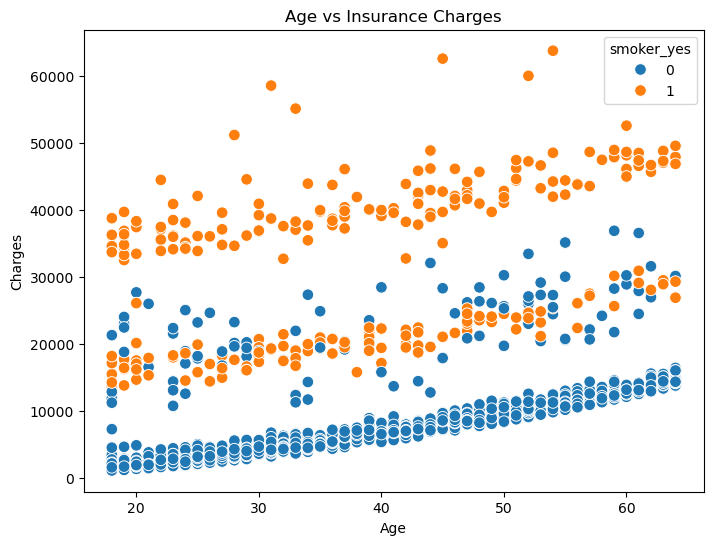

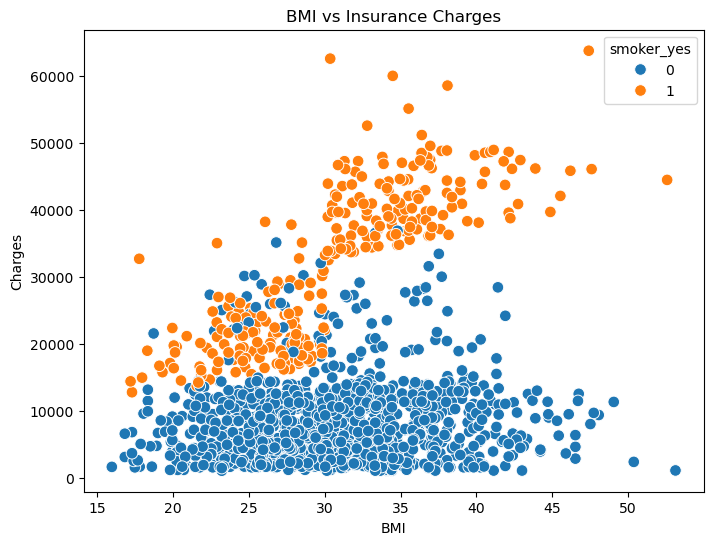

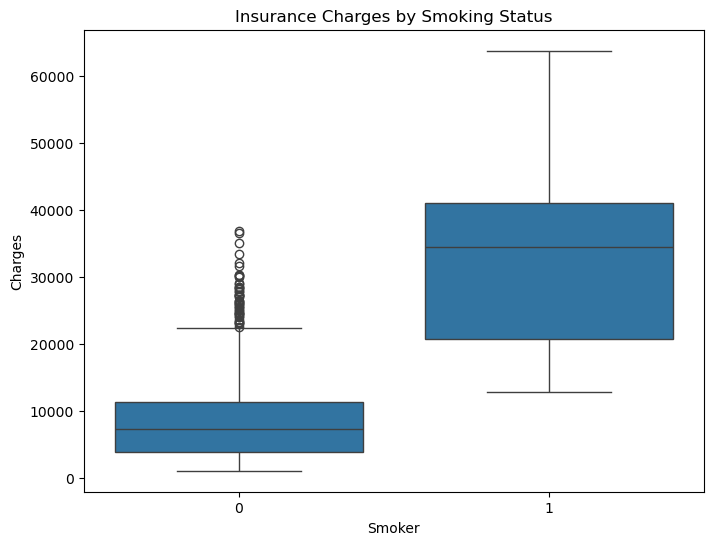

In [16]:
## 14. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=dataset, x="age", y="charges", hue="smoker_yes", s=70)
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=dataset, x="bmi", y="charges", hue="smoker_yes", s=70)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=dataset, x="smoker_yes", y="charges")
plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()


In [17]:
## 15. Saving the Trained Model
import pickle

filename = "LightGBM_Regression_Model.sav"
with open(filename, "wb") as file:
    pickle.dump(grid, file)
print("LightGBM regression model saved successfully.")


LightGBM regression model saved successfully.


In [18]:
## 16. Conclusion
# LightGBM regression was used to predict medical insurance charges.
# GridSearchCV was used to tune model parameters, and the trained
# model was saved for later prediction.
